In [1]:
# ============ #
# 1. LIBRERÍAS #
# ============ #

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error


/tmp/ipykernel_15952/79229621.py:5: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
# =================== #
# 2. LECTURA DE RUTAS #
# =================== #

mainpath = os.path.join(os.getcwd(), "..", "..", "data", "raw")
filename = "job_salary_prediction_dataset.csv"
fullpath = os.path.join(mainpath, filename)


In [3]:
# ================= #
# 3. CARGA DE DATOS #
# ================= #

df = pd.read_csv(fullpath, sep=",")
pd.set_option('display.max_columns', None)


In [4]:
# ============================== #
# 4. IDENTIFICACIÓN DE VARIABLES #
# ============================== #

def variables(df = df):
    float_cols = df.select_dtypes(include='float64').columns.tolist()
    int_cols = df.select_dtypes(include='int64').columns.tolist()
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    target = 'salary'
    features = [col for col in float_cols + int_cols if col != target]
    return features, target, cat_cols

features, target, cat_cols = variables()


In [5]:
# ================ #
# 5. PREPROCESADOR #
# ================ #

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), features)
])


In [6]:
# =============================== #
# VISUALIZAR EL PRE-PROCESAMIENTO #
# =============================== #

preprocessor


ColumnTransformer(transformers=[('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['job_title', 'education_level', 'industry',
                                  'company_size', 'location', 'remote_work']),
                                ('num', StandardScaler(),
                                 ['experience_years', 'skills_count',
                                  'certifications'])])

In [7]:
# ========================= #
# 6. PARTICIÓN TRAIN / TEST #
# ========================= #

X = df[features + cat_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [8]:
# ========= #
# 7. MODELO RIDGE #
# ========= #

model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', Ridge())
])

model.fit(X_train, y_train)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['job_title',
                                                   'education_level',
                                                   'industry', 'company_size',
                                                   'location', 'remote_work']),
                                                 ('num', StandardScaler(),
                                                  ['experience_years',
                                                   'skills_count',
                                                   'certifications'])])),
                ('regressor', Ridge())])

In [9]:
# ============== #
# 8. EVALUACIÓN  #
# ============== #

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)
print("MAPE(%):", mape * 100)
print("R2:", r2)


MAE: 5469.1335188766725
RMSE: 7170.541101674077
MAPE: 0.041612534477628194
MAPE(%): 4.161253447762819
R2: 0.9631041694844307


In [10]:
# ======================================== #
# 8.1. DATAFRAME CON RESULTADOS Y ERRORES  #
# ======================================== #

X_test_df = pd.DataFrame(X_test).reset_index(drop=True)
y_test_df = pd.Series(y_test).reset_index(drop=True)
y_pred_df = pd.Series(y_pred)

df_resultados = X_test_df.copy()
df_resultados["y_real"] = y_test_df
df_resultados["y_pred"] = y_pred_df
df_resultados["error"] = df_resultados["y_real"] - df_resultados["y_pred"]
df_resultados["abs_error"] = df_resultados["error"].abs()

df_resultados.sample(20)


,experience_years,skills_count,certifications,job_title,education_level,industry,company_size,location,remote_work,y_real,y_pred,error,abs_error
58621,10,6,4,Software Engineer,Master,Technology,Small,Netherlands,Hybrid,126936,128567.569772,-1631.569772,1631.569772
2620,16,11,1,Product Manager,High School,Finance,Enterprise,Sweden,No,178940,174171.066491,4768.933509,4768.933509
47447,20,8,0,Software Engineer,Bachelor,Education,Enterprise,Remote,Hybrid,175471,175335.914859,135.085141,135.085141
741,4,7,3,Cloud Engineer,Bachelor,Education,Enterprise,Remote,No,144921,146924.994017,-2003.994017,2003.994017
47886,6,14,5,Cloud Engineer,High School,Consulting,Enterprise,Germany,Yes,170806,170090.824563,715.175437,715.175437
10473,1,2,3,DevOps Engineer,Master,Retail,Enterprise,UK,No,161539,164179.045225,-2640.045225,2640.045225
40798,13,10,2,Backend Developer,High School,Manufacturing,Medium,UK,Hybrid,137859,141253.763771,-3394.763771,3394.763771
21400,14,11,1,Product Manager,Diploma,Healthcare,Small,India,No,98005,96978.416158,1026.583842,1026.583842
8338,1,2,0,Backend Developer,Bachelor,Manufacturing,Startup,India,No,57217,32518.078098,24698.921902,24698.921902
32570,6,10,2,Data Analyst,PhD,Manufacturing,Large,India,No,91295,86534.839597,4760.160403,4760.160403


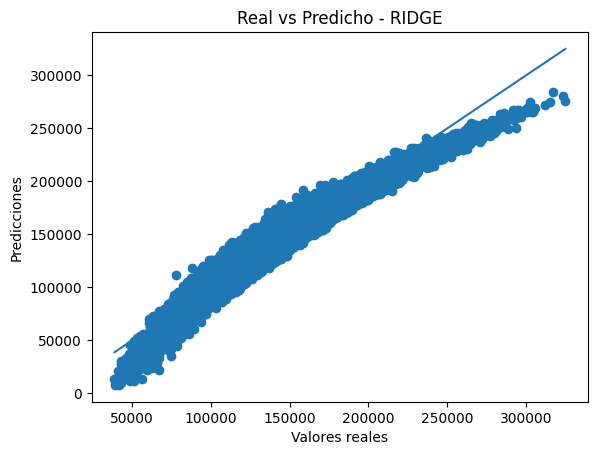

In [11]:
# ====================== #
# 8.2. REAL VS PREDICHO  #
# ====================== #

plt.scatter(df_resultados["y_real"], df_resultados["y_pred"])
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Real vs Predicho - RIDGE")
plt.plot(
    [df_resultados["y_real"].min(), df_resultados["y_real"].max()],
    [df_resultados["y_real"].min(), df_resultados["y_real"].max()]
)
plt.show()


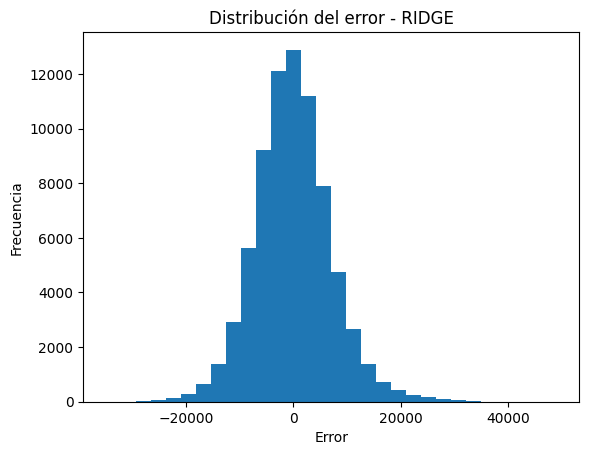

In [12]:
# ============================= #
# 8.3. DISTRIBUCIÓN DE ERRORES  #
# ============================= #

plt.hist(df_resultados["error"], bins=30)
plt.title("Distribución del error - RIDGE")
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.show()
